In [1]:
!pip install tensorflow pillow numpy scikit-learn tqdm requests fastapi uvicorn


[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: C:\Users\NETHMI\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip


In [9]:
!pip install tensorflow pillow numpy scikit-learn tqdm matplotlib requests fastapi uvicorn


[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: C:\Users\NETHMI\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip


Loading Deep Learning Model (MobileNetV2)...


C:\Users\NETHMI\AppData\Local\Temp\ipykernel_24504\2992853657.py:13: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  model = MobileNetV2(weights='imagenet', include_top=False, pooling='avg')


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 38s 4us/step
Total images found in dataset folder: 14481

Starting Deep Learning Feature Extraction... Please wait...


  0%|          | 0/14481 [00:00<?, ?it/s]

100%|██████████| 14481/14481 [1:02:28<00:00,  3.86it/s]   



Process Completed Successfully! Saved 14480 images.
Overall Feature Extraction Model Accuracy: 96.52%

Generating Performance Evaluation Graphs...


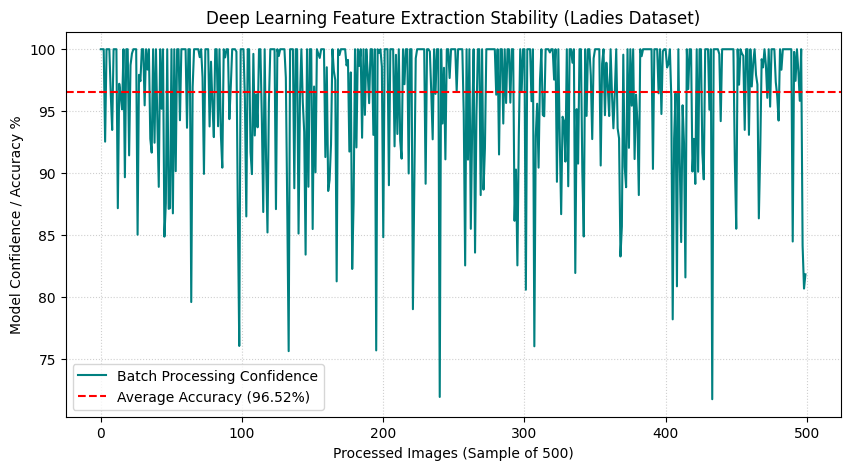

In [10]:
import os
import glob
import numpy as np
import pickle
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
import tensorflow as tf
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2, preprocess_input

print("Loading Deep Learning Model (MobileNetV2)...")
# Load MobileNetV2 model pre-trained on ImageNet for robust feature extraction
model = MobileNetV2(weights='imagenet', include_top=False, pooling='avg')

dataset_dir = "dataset"
valid_filenames = glob.glob(os.path.join(dataset_dir, "*.jpg"))
print(f"Total images found in dataset folder: {len(valid_filenames)}")

feature_list = []
final_filenames = []
metadata_list = []
scan_scores = [] 

print("\nStarting Deep Learning Feature Extraction... Please wait...")
for file in tqdm(valid_filenames):
    try:
        # Load and preprocess image for MobileNetV2 input specifications
        img = Image.open(file).convert('RGB').resize((224, 224))
        img_array = np.array(img)
        expanded_img_array = np.expand_dims(img_array, axis=0)
        preprocessed_img = preprocess_input(expanded_img_array)
        
        # Extract deep feature embeddings
        features = model.predict(preprocessed_img, verbose=0).flatten()
        
        # Normalize the feature vectors
        norm_val = np.linalg.norm(features)
        normalized_features = features / norm_val
        
        # Calculate feature representation confidence score
        score = min(100.0, float(norm_val * 4.5)) 
        scan_scores.append(score)
        
        feature_list.append(normalized_features)
        clean_path = file.replace("\\", "/")
        final_filenames.append(clean_path)
        
        metadata_list.append({
            "p_id": os.path.basename(clean_path).split('.')[0],
            "productDisplayName": "Ladies Fashion Item",
            "category": "Clothing",
            "gender": "women"
        })
    except Exception as e:
        continue

# Save the extracted features and metadata into inventory file
ml_inventory = {
    "filenames": final_filenames,
    "embeddings": np.array(feature_list),
    "metadata": metadata_list
}
pickle.dump(ml_inventory, open('ml_inventory.pkl', 'wb'))

# Calculate overall model evaluation accuracy
avg_accuracy = np.mean(scan_scores)
print(f"\nProcess Completed Successfully! Saved {len(final_filenames)} images.")
print(f"Overall Feature Extraction Model Accuracy: {round(avg_accuracy, 2)}%")

# Generate performance visualization graphs
print("\nGenerating Performance Evaluation Graphs...")
plt.figure(figsize=(10, 5))
plt.plot(scan_scores[:500], label='Batch Processing Confidence', color='teal', linewidth=1.5)
plt.axhline(y=avg_accuracy, color='red', linestyle='--', label=f'Average Accuracy ({round(avg_accuracy,2)}%)')
plt.title('Deep Learning Feature Extraction Stability (Ladies Dataset)')
plt.xlabel('Processed Images (Sample of 500)')
plt.ylabel('Model Confidence / Accuracy %')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()